In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [138]:
!unzip '/content/drive/MyDrive/Group E.zip'

Archive:  /content/drive/MyDrive/Group E.zip
   creating: Group E/
   creating: Group E/Raa_End/
  inflating: Group E/Raa_End/AHCR_00001_Raa_End_54.jpg  
  inflating: Group E/Raa_End/AHCR_00001_Raa_End_55.jpg  
  inflating: Group E/Raa_End/AHCR_00001_Raa_End_62.jpg  
  inflating: Group E/Raa_End/AHCR_00001_Raa_End_63.jpg  
  inflating: Group E/Raa_End/AHCR_00002_Raa_End_54.jpg  
  inflating: Group E/Raa_End/AHCR_00002_Raa_End_55.jpg  
  inflating: Group E/Raa_End/AHCR_00002_Raa_End_62.jpg  
  inflating: Group E/Raa_End/AHCR_00002_Raa_End_63.jpg  
  inflating: Group E/Raa_End/AHCR_00003_Raa_End_54.jpg  
  inflating: Group E/Raa_End/AHCR_00003_Raa_End_55.jpg  
  inflating: Group E/Raa_End/AHCR_00003_Raa_End_62.jpg  
  inflating: Group E/Raa_End/AHCR_00003_Raa_End_63.jpg  
  inflating: Group E/Raa_End/AHCR_00004_Raa_End_54.jpg  
  inflating: Group E/Raa_End/AHCR_00004_Raa_End_55.jpg  
  inflating: Group E/Raa_End/AHCR_00004_Raa_End_62.jpg  
  inflating: Group E/Raa_End/AHCR_00004_Raa_End_

In [139]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group E"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))  
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path): 
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 2251, Testing samples: 563
Number of classes: 6


In [141]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [142]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [143]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.1968 - loss: 1.8457 - val_accuracy: 0.3819 - val_loss: 1.3872
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.3853 - loss: 1.4344 - val_accuracy: 0.5417 - val_loss: 1.1748
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4072 - loss: 1.3467 - val_accuracy: 0.4760 - val_loss: 1.1760
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.5242 - loss: 1.1738 - val_accuracy: 0.6590 - val_loss: 0.8853
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6143 - loss: 0.9615 - val_accuracy: 0.7016 - val_loss: 0.8865
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.6967 - loss: 0.8273 - val_accuracy: 0.8686 - val_loss: 0.4705
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7812 - loss: 0.6606 - val_accuracy: 0.8526 - val_loss: 0.4497
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.8214 - loss: 0.5394 - val_accuracy: 0.

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9446 - loss: 0.2173
Train Accuracy: 90.58%
Test Accuracy: 94.32%


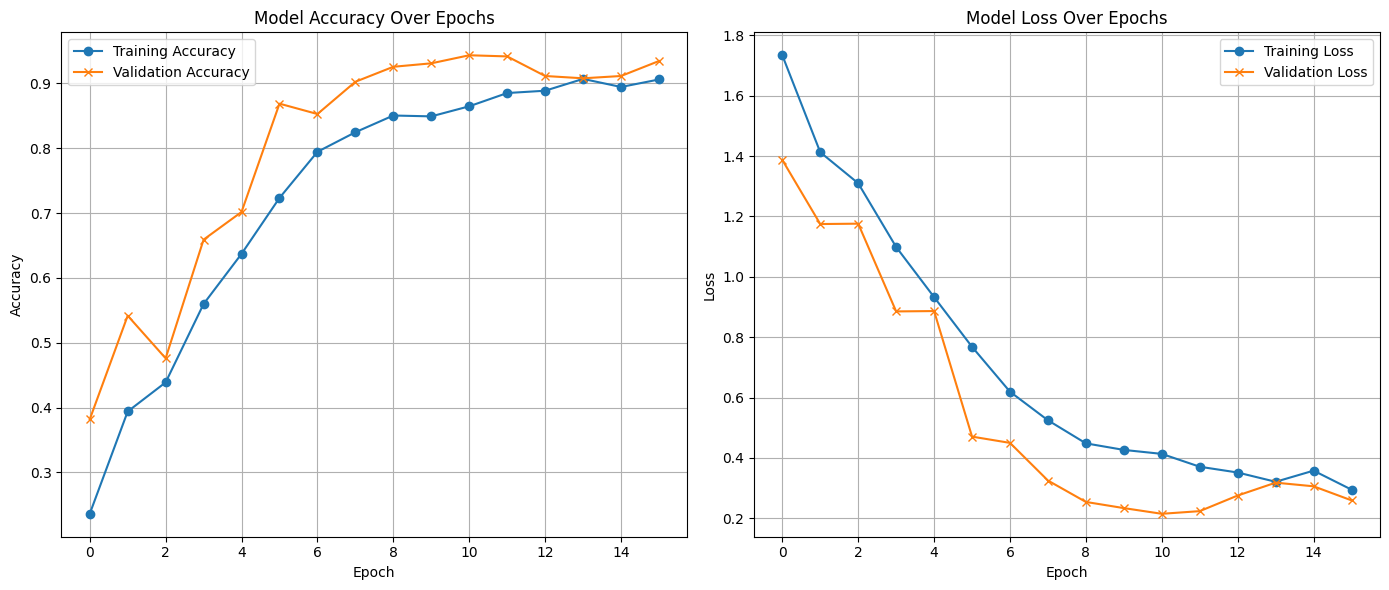

In [144]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


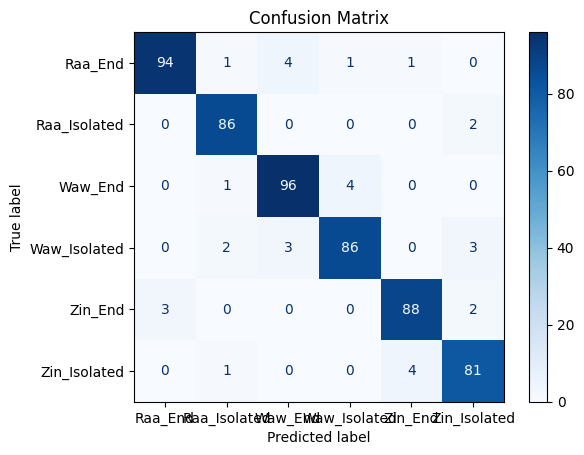

In [145]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


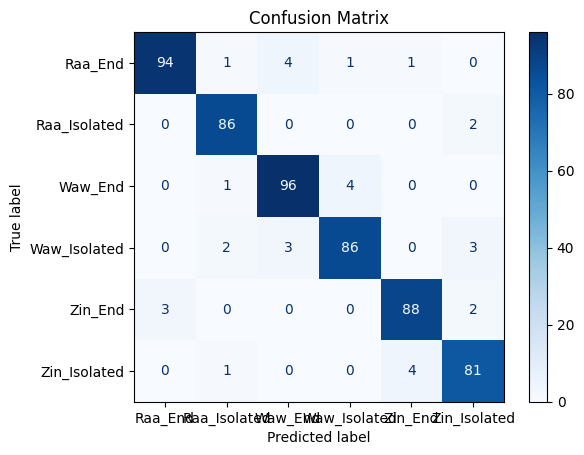

Number of incorrect predictions: 32


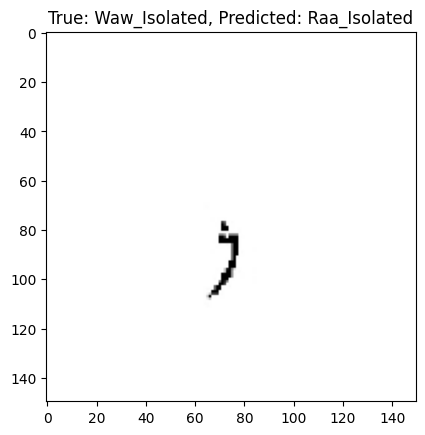

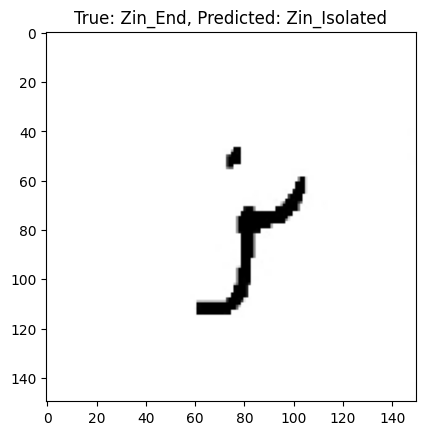

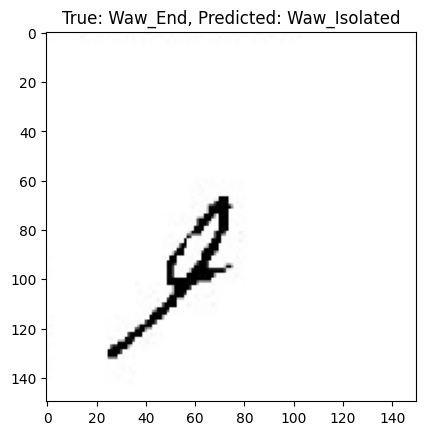

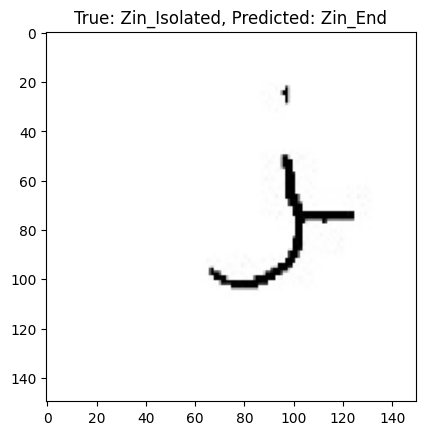

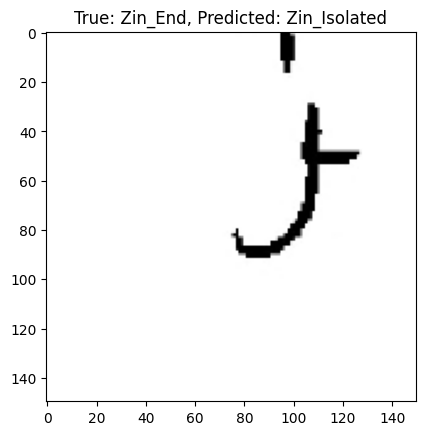

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### reduce data augmentation (zoom_range) and decrease dropOut

In [148]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.01,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [149]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [150]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.1969 - loss: 1.8271 - val_accuracy: 0.4298 - val_loss: 1.3191
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.3843 - loss: 1.4084 - val_accuracy: 0.4813 - val_loss: 1.1563
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.5445 - loss: 1.1276 - val_accuracy: 0.5773 - val_loss: 1.0312
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6674 - loss: 0.8521 - val_accuracy: 0.7691 - val_loss: 0.7031
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7627 - loss: 0.6474 - val_accuracy: 0.8313 - val_loss: 0.5009
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8208 - loss: 0.5213 - val_accuracy: 0.8259 - val_loss: 0.4690
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8808 - loss: 0.3797 - val_accuracy: 0.7993 - val_loss: 0.5826
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9001 - loss: 0.3211 - val_accuracy: 0

In [151]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9315 - loss: 0.2105
Train Accuracy: 94.85%
Test Accuracy: 93.25%


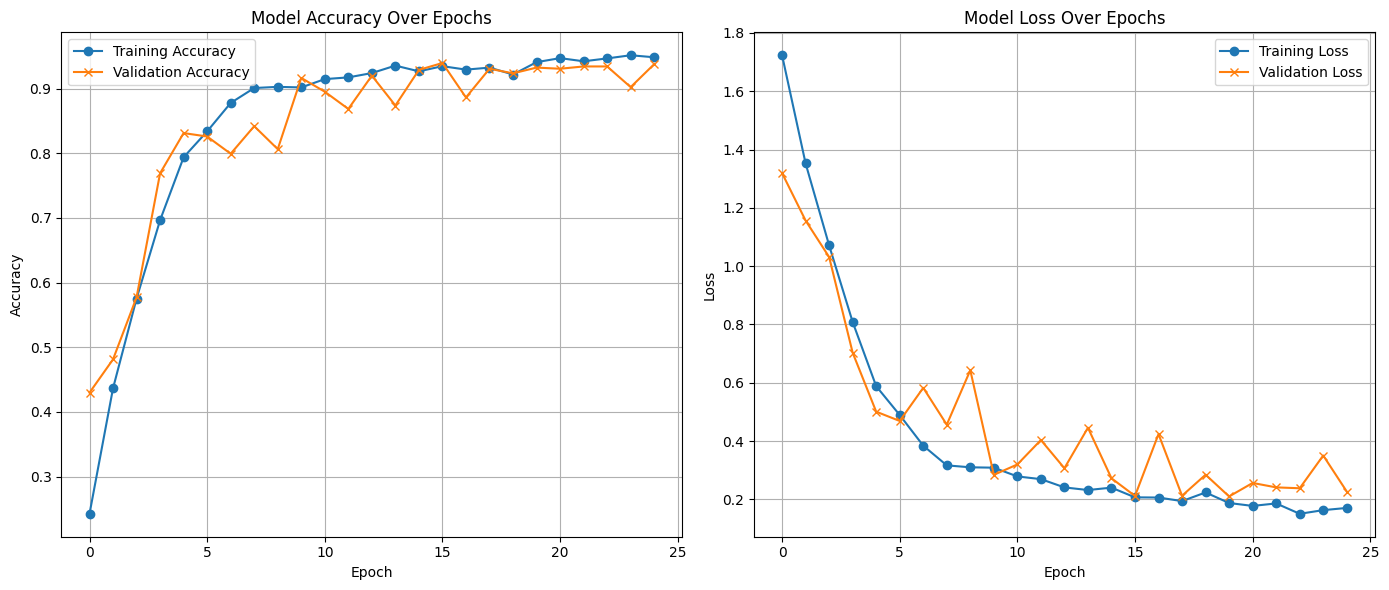

In [152]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


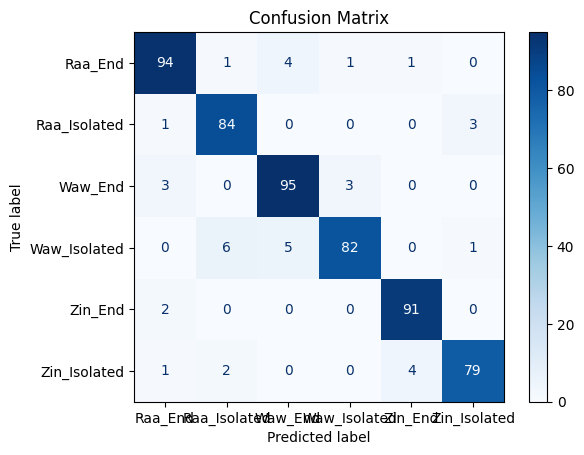

Number of incorrect predictions: 38


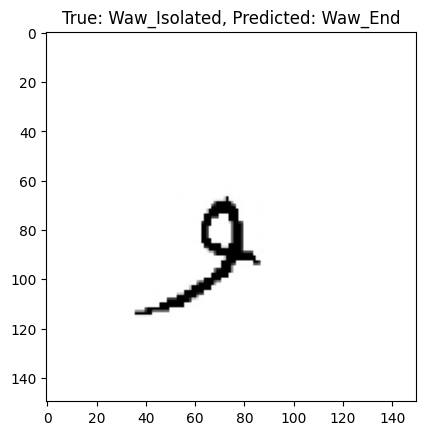

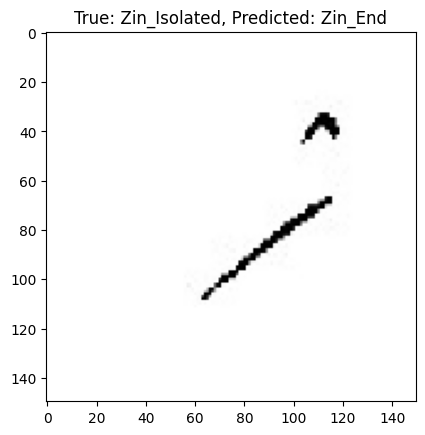

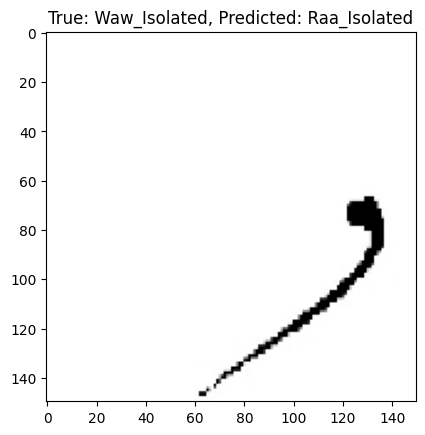

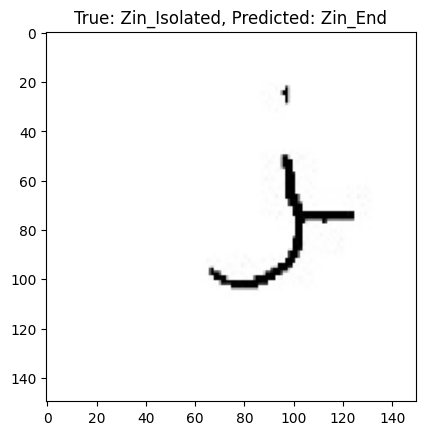

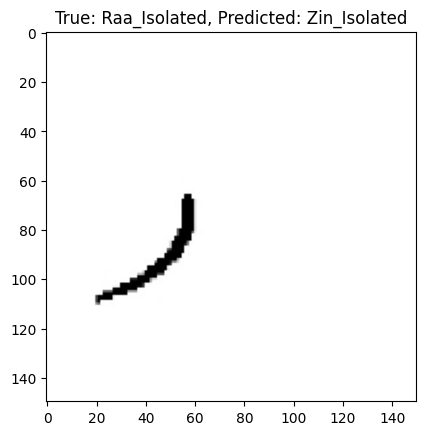

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [154]:
model.save("GrpE.keras")